## Problem 2: Linear regression with mini-batch gradient descent

Model: $h_\theta(x) = \theta_0 + \theta_1 x$, where $x$ is city population (in 10,000s) and $y$ is house price (in \$10,000s).

Objective: $J(\theta) = \dfrac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)^2$

Mini-batch update for a batch $B$: $\theta \leftarrow \theta - \dfrac{\alpha}{|B|}\sum_{i \in B} \left(h_\theta(x^{(i)}) - y^{(i)}\right) x^{(i)}$

Number of samples: 97


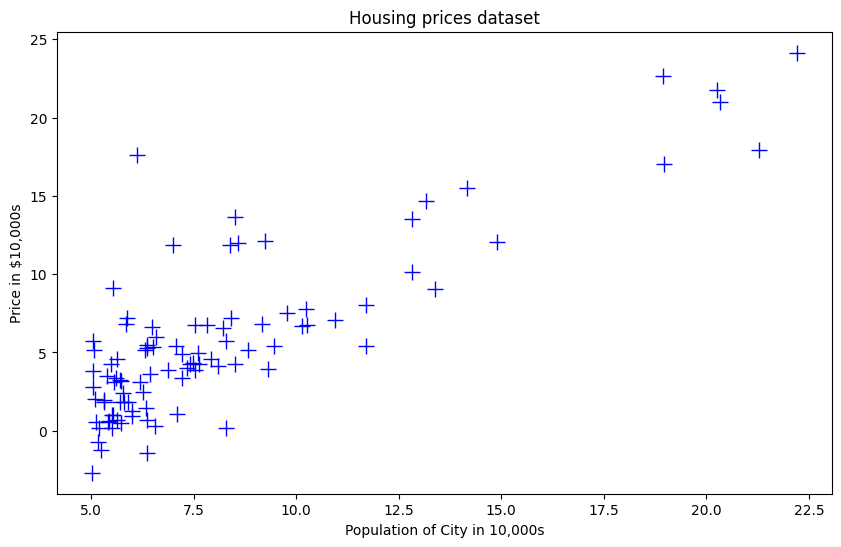

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('housing_prices.txt', delimiter=',')
x, y = data[:, 0], data[:, 1]
m = y.size
print('Number of samples:', m)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b+', markersize=12)
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Price in $10,000s')
plt.title('Housing prices dataset')
plt.show()

In [2]:
# Standardize the feature so one learning rate works for every batch size,
# then add a column of ones for the intercept term
mu, sigma = x.mean(), x.std()
X = np.column_stack([np.ones(m), (x - mu) / sigma])

print(X[:5])

[[ 1.         -0.53240565]
 [ 1.         -0.68368294]
 [ 1.          0.09319761]
 [ 1.         -0.30042464]
 [ 1.         -0.5974206 ]]


In [3]:
def cost(X, y, theta):
    # J(theta) = 1/(2m) * sum of squared residuals
    r = X @ theta - y
    return r @ r / (2 * len(y))


def minibatch_gd(X, y, batch_size, alpha=0.01, epochs=200, seed=0):
    rng = np.random.default_rng(seed)
    m = len(y)
    theta = np.zeros(X.shape[1])
    J_hist = [cost(X, y, theta)]
    for _ in range(epochs):
        # Reshuffle every epoch, then sweep through the data one mini-batch at a time
        idx = rng.permutation(m)
        for start in range(0, m, batch_size):
            b = idx[start:start + batch_size]
            grad = X[b].T @ (X[b] @ theta - y[b]) / len(b)
            theta = theta - alpha * grad
            # Record J on the full dataset after every parameter update
            J_hist.append(cost(X, y, theta))
    return theta, np.array(J_hist)


def predict(theta, pop):
    # pop is in 10,000s; apply the same scaling used in training
    return theta[0] + theta[1] * (pop - mu) / sigma

In [4]:
alpha = 0.01
epochs = 200
batch_sizes = [1, 5, 10, 20]
pop_query = 16.0  # 160,000 people

# Closed-form least-squares solution, used only as a reference to check convergence
theta_ne = np.linalg.solve(X.T @ X, X.T @ y)

results = {}
for bs in batch_sizes:
    theta, J_hist = minibatch_gd(X, y, bs, alpha=alpha, epochs=epochs)
    results[bs] = (theta, J_hist)

print(f"{'Batch':>5} {'Updates':>8} {'theta0':>8} {'theta1':>8} {'Final J':>8} {'Price @ 160k':>14}")
for bs, (theta, J_hist) in results.items():
    price = predict(theta, pop_query) * 10000
    print(f"{bs:>5} {len(J_hist) - 1:>8} {theta[0]:>8.4f} {theta[1]:>8.4f} {J_hist[-1]:>8.4f} {price:>14,.2f}")
print(f"{'Exact':>5} {'-':>8} {theta_ne[0]:>8.4f} {theta_ne[1]:>8.4f} {cost(X, y, theta_ne):>8.4f} "
      f"{predict(theta_ne, pop_query) * 10000:>14,.2f}")

Batch  Updates   theta0   theta1  Final J   Price @ 160k
    1    19400   5.8442   4.6462   4.4784     153,060.28
    5     4000   5.8038   4.5924   4.4776     151,560.15
   10     2000   5.8299   4.5990   4.4770     151,955.84
   20     1000   5.8390   4.5900   4.4770     151,864.77
Exact        -   5.8391   4.5930   4.4770     151,927.57


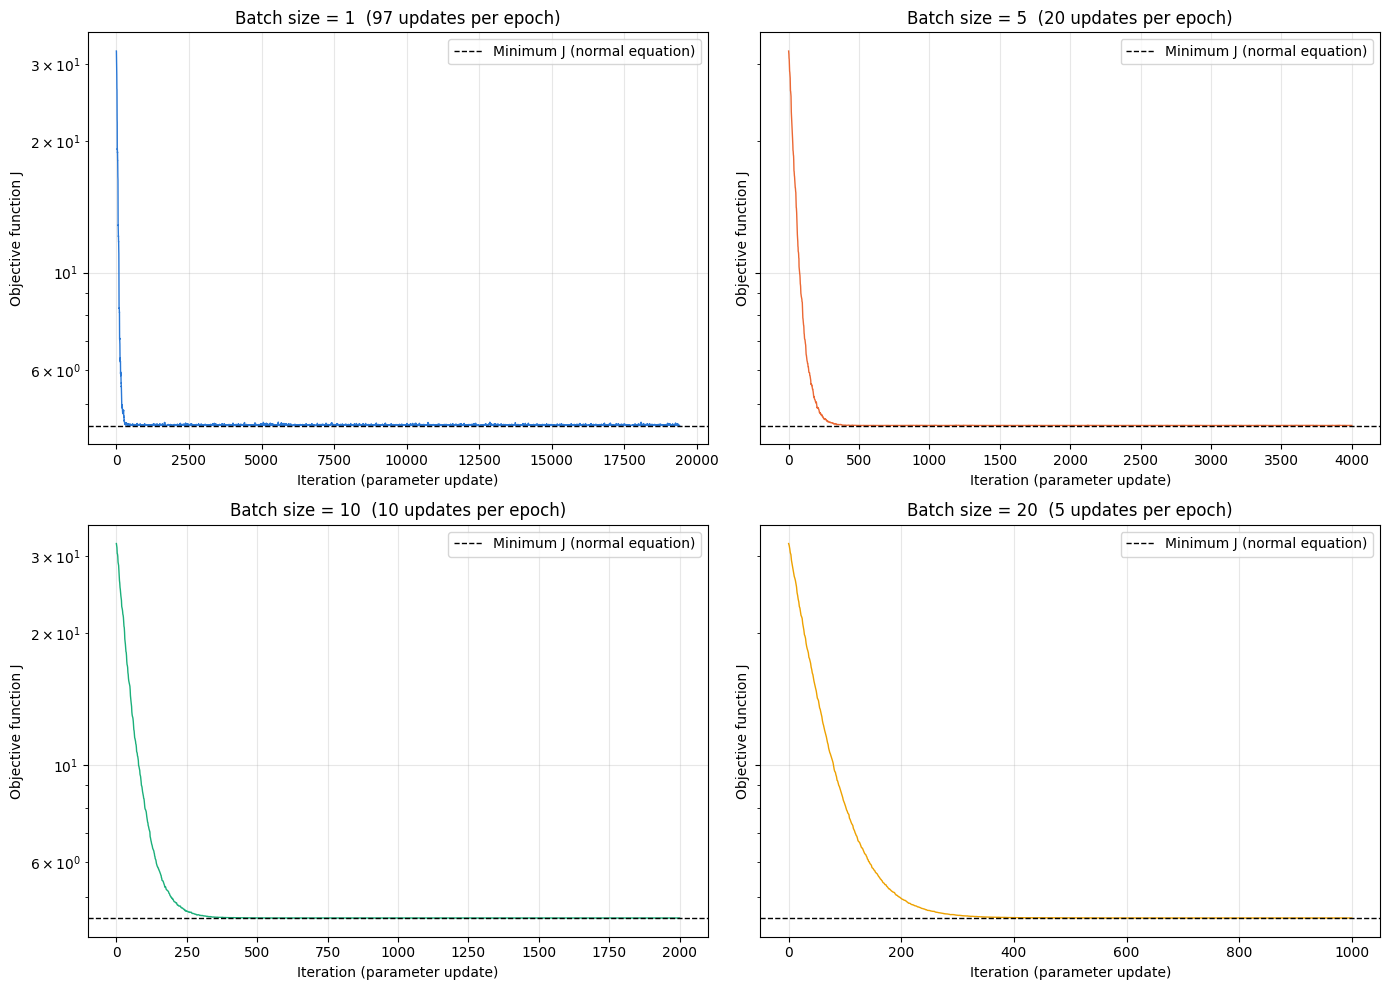

In [5]:
colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
for ax, bs, c in zip(axes.flat, batch_sizes, colors):
    theta, J_hist = results[bs]
    ax.plot(np.arange(len(J_hist)), J_hist, color=c, linewidth=1)
    ax.axhline(cost(X, y, theta_ne), color='k', linestyle='--', linewidth=1, label='Minimum J (normal equation)')
    ax.set_yscale('log')
    ax.set_title(f'Batch size = {bs}  ({int(np.ceil(m / bs))} updates per epoch)')
    ax.set_xlabel('Iteration (parameter update)')
    ax.set_ylabel('Objective function J')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

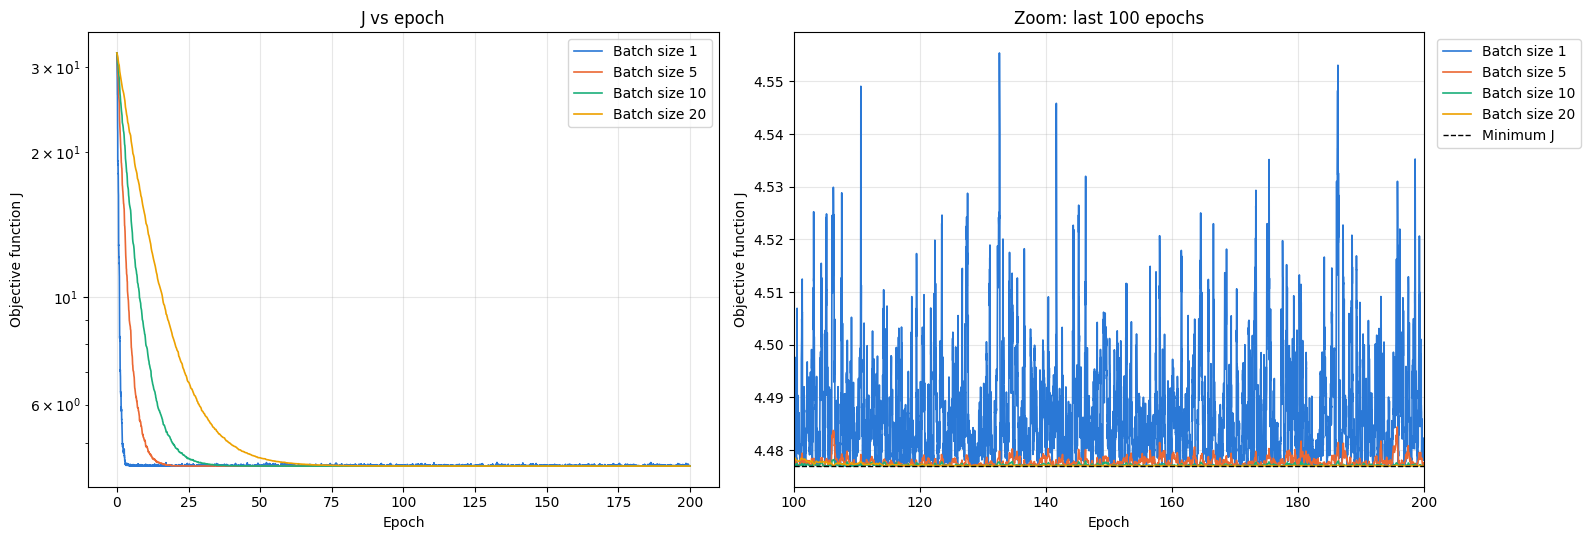

In [6]:
# Same J histories on a common x-axis (epochs) to compare batch sizes directly
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
for bs, c in zip(batch_sizes, colors):
    theta, J_hist = results[bs]
    ep = np.arange(len(J_hist)) / np.ceil(m / bs)
    ax1.plot(ep, J_hist, color=c, linewidth=1.2, label=f'Batch size {bs}')
    ax2.plot(ep, J_hist, color=c, linewidth=1.2, label=f'Batch size {bs}')

ax1.set_yscale('log')
ax1.set_title('J vs epoch')

# Zoom in near the minimum to see the noise around convergence
J_min = cost(X, y, theta_ne)
J_top = max(J[len(J) // 2:].max() for _, J in results.values())
ax2.axhline(J_min, color='k', linestyle='--', linewidth=1, label='Minimum J')
ax2.set_xlim(100, epochs)
ax2.set_ylim(J_min - 0.05 * (J_top - J_min), J_top + 0.05 * (J_top - J_min))
ax2.set_title('Zoom: last 100 epochs')

for ax in (ax1, ax2):
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Objective function J')
    ax.grid(alpha=0.3)
ax1.legend()
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

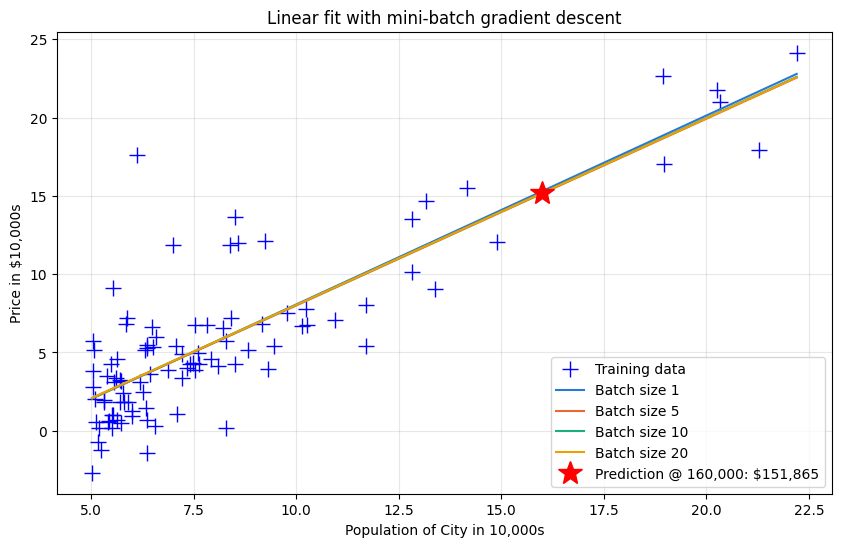

In [7]:
# Fitted lines from every batch size over the data
x_line = np.linspace(x.min(), x.max(), 100)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b+', markersize=12, label='Training data')
for bs, c in zip(batch_sizes, colors):
    plt.plot(x_line, predict(results[bs][0], x_line), color=c, label=f'Batch size {bs}')
price_query = predict(results[20][0], pop_query)
plt.plot(pop_query, price_query, 'r*', markersize=18,
         label=f'Prediction @ 160,000: ${price_query * 10000:,.0f}')
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Price in $10,000s')
plt.title('Linear fit with mini-batch gradient descent')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Results

All four models were trained with the same learning rate ($\alpha = 0.01$) and the same number of epochs (200), starting from $\theta = 0$. Every batch size converges to essentially the least-squares solution ($J_{min} \approx 4.477$). The predicted price of a house in a city of **160,000** people is about **\$151,900** (normal equation: \$151,928; mini-batch results range from about \$151,560 to \$153,060 depending on batch size).

**Effect of batch size**
- **Smaller batches make more updates per epoch.** With 97 samples, batch size 1 makes 97 updates per epoch, while batch size 20 makes only 5. So per epoch, small batches drive $J$ down much faster: batch size 1 reaches the minimum in about 3 epochs, while batch size 20 needs about 60.
- **Larger batches give smoother descent.** Each gradient is averaged over more samples, so it is closer to the true full-batch gradient and $J$ decreases almost monotonically.

### What happens when batch size = 1?

Batch size 1 is **stochastic gradient descent (SGD)**: each update uses the gradient of a single sample, which is a very noisy estimate of the true gradient.
- $J$ drops quickly at first (many cheap updates per epoch), but the curve is **jagged**, and $J$ can go **up** after an individual update when that sample points away from the overall minimum.
- With a constant learning rate, it **never settles exactly at the minimum**. It keeps bouncing around in a small region near it. In the zoomed plot, $J$ for batch size 1 spikes up to about 4.55 (≈1.7% above $J_{min}$), while batch sizes 10 and 20 stay flat on the minimum. Its final parameters, and therefore its predicted price, also differ the most from the exact solution.
- It is also the least efficient computationally: one update per sample means no vectorization across the batch. In practice, a decaying learning rate or a larger batch is used to reduce the noise near convergence.

Batch sizes 5 to 20 balance these trade-offs: they have less gradient noise than SGD and make more updates per epoch than full-batch gradient descent.